<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Calum_MBTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TEMPLATE FILE 
* Run the first cell to install all dependencies, download all data, and process all molecules into needed lists
* **SAVE A COPY TO GITHUB WITH A DIFFERENT NAME OR THIS WILL BE OVERWRITTEN**

In [1]:
# RUN THIS CELL 

! pip install dscribe  # Downloads needed modules
! pip install ase

# -------------------------------------------------------

import io
from datetime import datetime
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from ase.io import read
from sklearn.model_selection import train_test_split

def download_published_data():
  """Downloads and unzips data folder.
  """


  start = datetime.now()
  print(start)
  r = requests.get('https://people.bath.ac.uk/crh53/m1507656.zip')
  zipped = zipfile.ZipFile(io.BytesIO(r.content))
  zipped.extractall('')
  finish = datetime.now()
  print(finish)
  print(finish - start)

def xyz_str_to_atoms(xyz_str):
  """
  Convert a xyz file to an ASE atoms object via in-memory file (StringIO).
  """
  f = io.StringIO()
  f.write(xyz_str)
  f.seek(0)
  atoms = read(f, format="xyz")
  return atoms

# -------------------------------------------------------

print('Downloading data...')
download_published_data()  # downloads needed data
% cd m1507656

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

print('Loading data...')
df = pd.read_json('df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_str_to_atoms)

print('Extracting HOMO from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)

print('Splitting data set...')
train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

     |████████████████████████████████| 143 kB 5.2 MB/s 
  Using cached pybind11-2.7.1-py2.py3-none-any.whl (200 kB)
     |████████████████████████████████| 2.2 MB 49.9 MB/s 
     |████████████████████████████████| 76 kB 4.6 MB/s 
  Created wheel for dscribe: filename=dscribe-1.1.0-cp37-cp37m-linux_x86_64.whl size=4339857 sha256=6cac0525590dbcb0eb911400d46d33c8686c8e398c4ec08109b8376c267dba57
  Stored in directory: /root/.cache/pip/wheels/05/f8/a6/c5328c447d56d1efed920c372cbd0086ac1e01de1b5adaa9db
Successfully built dscribe
2021-08-23 13:14:51.427694
2021-08-23 13:15:20.342751
0:00:28.915057
/content/m1507656
Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO from data...
Splitting data set...
Data Processing Complete
# -----------------------------------------------------------------------------------------------------------------------


## Helpful variables
>* Needed if you need to list all elements included in your train and testing datasets

In [2]:
atomic_numbers = df['atoms'].apply(lambda x: x.numbers)
unique_atomic_numbers = set([a for b in atomic_numbers for a in b])
num_atoms = atomic_numbers.apply(len)
max_num_atoms = num_atoms.max()

print(unique_atomic_numbers)
print(max_num_atoms)

{1, 34, 35, 33, 5, 6, 7, 8, 9, 3, 14, 15, 16, 17, 53}
100


## `MBTR` Generation
* Going to try the `k2` and `k3` separately for the moment to see how that turns out
* Rough testing indicates `k2` is more reliable feature (also faster to calculate and produces smaller feature vector making resultant model training and assessment much quicker)
* Do a quick `t-SNE` visualisation on a subsample

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from dscribe.descriptors import MBTR

In [6]:
n = 35

feature_calc = MBTR(
    species=unique_atomic_numbers,
    k2={
        "geometry": {"function": "inverse_distance"},
        "grid": {"min": 0, "max": 1, "n": n, "sigma": 0.1},
        "weighting": {"function": "exp", "scale": 0.5, "threshold": 1e-3},
    },
    periodic=False,
    normalization="l2_each",
)

In [7]:
mol = df['atoms'].iloc[0]
out = feature_calc.create(mol, n_jobs=-1)

print(len(mol), n, '-->', out.shape)

30 35 --> (4200,)


In [8]:
print('Generating features...')
X_train, X_test = (np.vstack([feature_calc.create(a) for a in d]) for d in (train_atoms, test_atoms))
print('Features generated.')

Generating features...
Features generated.


In [9]:
level = 'HOMO'
y_train, y_test = (d[level].values for d in (train, test))

* Seems that there is some structure to the `t-SNE` projection with low energy levels occupying the periphery (although that could just be sampling bias with not many low energy molecules...)
* Does build confidence that the features contain a reasonable mapping however between feature space and target values

___
## KernelRidge Prediction

In [12]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

In [25]:
pipe = Pipeline([
              ('x_norm', StandardScaler()),
              ('estimator', KernelRidgeRegressor())
])

In [26]:
# iterate through different alpha values and generate train test curves for them

parameters = [{
    'estimator__alpha': np.logspace(-6, 3, 10),
    'estimator__gamma': np.logspace(-3, 3, 7),
    'estimator__kernel': ['rbf', 'laplacian']
}]

grid = GridSearchCV(pipe, param_grid=parameters, scoring='neg_mean_absolute_error', n_jobs=-1, cv=3, verbose=4)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 140 candidates, totalling 420 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  6.3min
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed: 30.2min
[Parallel(n_jobs=-1)]: Done 217 tasks      | elapsed: 70.0min
[Parallel(n_jobs=-1)]: Done 388 tasks      | elapsed: 125.7min
[Parallel(n_jobs=-1)]: Done 420 out of 420 | elapsed: 136.4min finished


GridSearchCV(cv=3, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('x_norm',
                                        StandardScaler(copy=True,
                                                       with_mean=True,
                                                       with_std=True)),
                                       ('estimator',
                                        KernelRidgeRegressor(alpha=1, coef0=1,
                                                             degree=3,
                                                             gamma=None,
                                                             kernel='linear',
                                                             kernel_params=None))],
                                verbose=False),
             iid='deprecated', n_jobs=-1,
             param_grid=[{'estimator__alpha': array([1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01,
       1.e+02, 

In [27]:
results = pd.DataFrame(grid.cv_results_).sort_values(by='rank_test_score')
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__alpha,param_estimator__gamma,param_estimator__kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
71,47.114276,0.549167,23.267244,0.171366,0.1,0.001,laplacian,"{'estimator__alpha': 0.1, 'estimator__gamma': ...",-0.332083,-0.347666,-0.348735,-0.342828,0.007611,1
57,47.098955,0.722845,23.163363,0.099894,0.01,0.001,laplacian,"{'estimator__alpha': 0.01, 'estimator__gamma':...",-0.342098,-0.358407,-0.354333,-0.351613,0.006931,2
43,47.016627,0.541268,23.206541,0.179620,0.001,0.001,laplacian,"{'estimator__alpha': 0.001, 'estimator__gamma'...",-0.351762,-0.367552,-0.362693,-0.360669,0.006603,3
29,46.952344,0.519813,23.322739,0.064616,0.0001,0.001,laplacian,"{'estimator__alpha': 0.0001, 'estimator__gamma...",-0.353529,-0.369173,-0.364294,-0.362332,0.006536,4
15,46.888369,0.545537,23.118833,0.186538,1e-05,0.001,laplacian,"{'estimator__alpha': 1e-05, 'estimator__gamma'...",-0.353723,-0.369348,-0.364472,-0.362514,0.006528,5


In [28]:
estimator = grid.best_estimator_
print(estimator)

Pipeline(memory=None,
         steps=[('x_norm',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('estimator',
                 KernelRidgeRegressor(alpha=0.1, coef0=1, degree=3, gamma=0.001,
                                      kernel='laplacian',
                                      kernel_params=None))],
         verbose=False)


Best model determined by `GridSearchCV` used a laplcian kernel with alpha value of `0.1` and a gamma value of `0.001`

In [29]:
X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=20210820)

In [30]:
dummy = DummyRegressor()  # for reference
dummy.fit(X_tr, y_tr)
estimator.fit(X_tr, y_tr)


for mdl, label in zip((estimator, dummy), ('KRR', 'Dummy')):
  print()
  print(label, '------------------------------------')

  for s, X_ref, y_ref in zip(('train', 'cv'), (X_tr, X_cv), (y_tr, y_cv)):
    pred = mdl.predict(X_ref)
    mae = mean_absolute_error(y_ref, pred)
    mse = mean_squared_error(y_ref, pred)
    r2 = r2_score(y_ref, pred)

    print(F'{s} : mae={mae:.3f}, mse={mse:.3f}, r2={r2:.3f}')



KRR ------------------------------------
train : mae=0.174, mse=0.054, r2=0.919
cv : mae=0.330, mse=0.193, r2=0.724

Dummy ------------------------------------
train : mae=0.644, mse=0.674, r2=0.000
cv : mae=0.656, mse=0.700, r2=-0.000


* Model is achieving moderate results for a quick estimation
* Can see outperforms random / mean prediction based predictive methods so certainly a signal is being learned by the model
* Training score is notably higher than the testing score however...

In [45]:
db_sizes = [10, 100, 1000, 2000, 3000]
scores = {'train':[[] for _ in db_sizes], 'test':[[] for _ in db_sizes]}

for index, size in enumerate(db_sizes):
  print(size)
  for _ in range(3):
    print('\t', _)
    Xa, Xb, ya, yb  = train_test_split(X_train, y_train, train_size=size)
    estimator.fit(Xa, ya)
    tr_pred = estimator.predict(Xa)
    cv_pred = estimator.predict(Xb)

    scores['train'][index].append(mean_absolute_error(ya, tr_pred))
    scores['test'][index].append(mean_absolute_error(yb, cv_pred))

10
	 0
	 1
	 2
100
	 0
	 1
	 2
1000
	 0
	 1
	 2
2000
	 0
	 1
	 2
3000
	 0
	 1
	 2


In [47]:
train_scores = np.array(scores['train'])
test_scores = np.array(scores['test'])

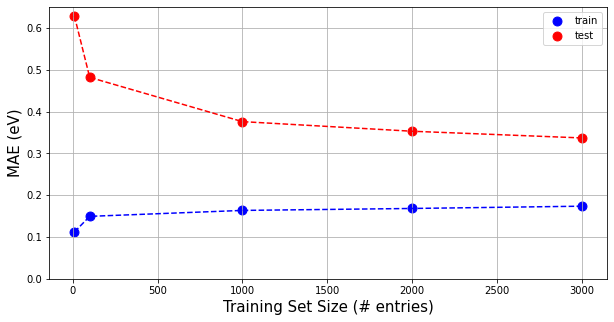

In [107]:
plt.figure(figsize=(10, 5))
plt.scatter(db_sizes, train_scores.mean(1), marker='o', label='train', s=80, c='b')
plt.plot(db_sizes, train_scores.mean(1), 'b--')
plt.scatter(db_sizes, test_scores.mean(1), marker='o', label='test', s=80, c='r')
plt.plot(db_sizes, test_scores.mean(1), 'r--')
plt.legend()
plt.xlabel('Training Set Size (# entries)', size=15)
plt.ylabel('MAE (eV)', size=15)
plt.ylim(0, 0.65)
plt.grid()
plt.savefig('MBTR_krr_overfit.png', bbox_inches=None)
plt.show()

* Indicates definitly that the returned CV model is overfitting to the data and so altogether not that reliable
* Takes a while to train and screen things though so going to stick with this since deadline tomorrow YOLO

In [34]:
# data for final parity plot
estimator.fit(X_train, y_train)
y_pred_train = estimator.predict(X_train)
y_pred_test = estimator.predict(X_test)

mae=0.6558546537875581, mse=0.6999878845336551, r2=-7.286258301819615e-06


In [73]:
print(F'Train : mae={mean_absolute_error(y_train, y_pred_train):.3f}, mse={mean_squared_error(y_train, y_pred_train):.3f}, r2={r2_score(y_train, y_pred_train):.3f}')
print(F'Test  : mae={mean_absolute_error(y_test, y_pred_test):.3f}, mse={mean_squared_error(y_test, y_pred_test):.3f}, r2={r2_score(y_test, y_pred_test):.3f}')

Train : mae=0.176, mse=0.055, r2=0.919
Test  : mae=0.340, mse=0.194, r2=0.710


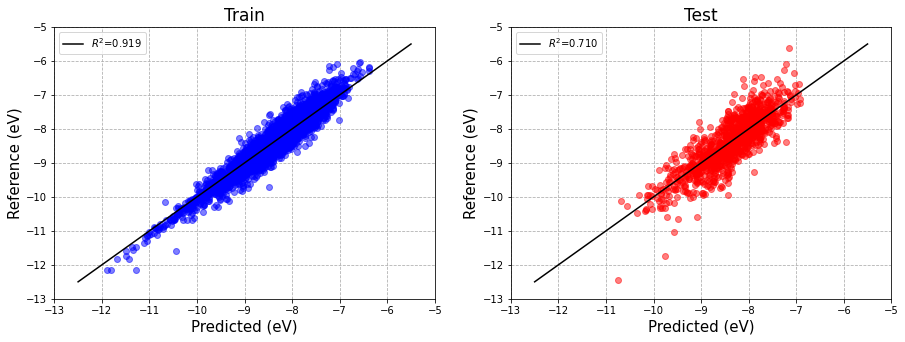

In [108]:
plt.figure(figsize=(15, 5))

arrs = [[y_pred_train, y_train], [y_pred_test, y_test]]
labels = ['Train', 'Test']
colors = ['b', 'r']
r2_vals = [0.919, 0.710]

for count, (pred, ref) in enumerate(arrs):
  plt.subplot(1, 2, count+1)
  plt.title(F'{labels[count]}', size=17)
  plt.plot(pred, ref, 'o', alpha=0.5, c=colors[count])
  plt.plot([-12.5, -5.5], [-12.5, -5.5], 'k-', label=F'$R^2$={r2_vals[count]:.3f}')
  plt.xlabel(F'Predicted (eV)', size=15)
  plt.ylabel('Reference (eV)', size=15)
  plt.xlim(-13, -5)
  plt.ylim(-13, -5)
  plt.grid(linestyle='--')
  plt.legend(loc='upper left')
plt.savefig('parity_plots.png', bbox_inches=None)
plt.show()

In [109]:
estimator

Pipeline(memory=None,
         steps=[('x_norm',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('estimator',
                 KernelRidgeRegressor(alpha=0.1, coef0=1, degree=3, gamma=0.001,
                                      kernel='laplacian',
                                      kernel_params=None))],
         verbose=False)